In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import yfinance as yf
import datetime
import math as m
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
%matplotlib inline

In [2]:
# =============================================================================
# Portfolio Risk & Return Analysis: A Multi-Asset Study Across Sectors
# Author: Angelos
# Period: 2019-01-01 to 2024-12-31
# Assets: AAPL, MSFT, JPM, JNJ, PG, XOM | Benchmark: S&P 500 (^GSPC)
# =============================================================================

# Imports & Data Collection

In [3]:
stocks = ["AAPL", "MSFT", "JPM", "JNJ", "PG", "XOM"]
assets = stocks + ["^GSPC"]
data = yf.download(assets, start="2019-01-01", end="2024-12-31")["Close"]
print("Shape:", data.shape)
print(data.head())
print(data.tail())

[*********************100%***********************]  7 of 7 completed

Shape: (1509, 7)
Ticker           AAPL         JNJ        JPM       MSFT         PG        XOM  \
Date                                                                            
2019-01-02  37.503735  104.387886  80.836517  94.397156  75.348259  50.001842   
2019-01-03  33.768078  102.729134  79.687675  90.924469  74.819954  49.234127   
2019-01-04  35.209614  104.453270  82.625412  95.153297  76.347076  51.049381   
2019-01-07  35.131245  103.783218  82.682846  95.274658  76.041634  51.314850   
2019-01-08  35.800964  106.193748  82.526947  95.965469  76.322304  51.687946   

Ticker            ^GSPC  
Date                     
2019-01-02  2510.030029  
2019-01-03  2447.889893  
2019-01-04  2531.939941  
2019-01-07  2549.689941  
2019-01-08  2574.409912  
Ticker            AAPL         JNJ         JPM        MSFT          PG  \
Date                                                                     
2024-12-23  253.883118  140.209885  231.216553  431.078888  161.412735   
2024-12-24 

# Normalization & Price Performance

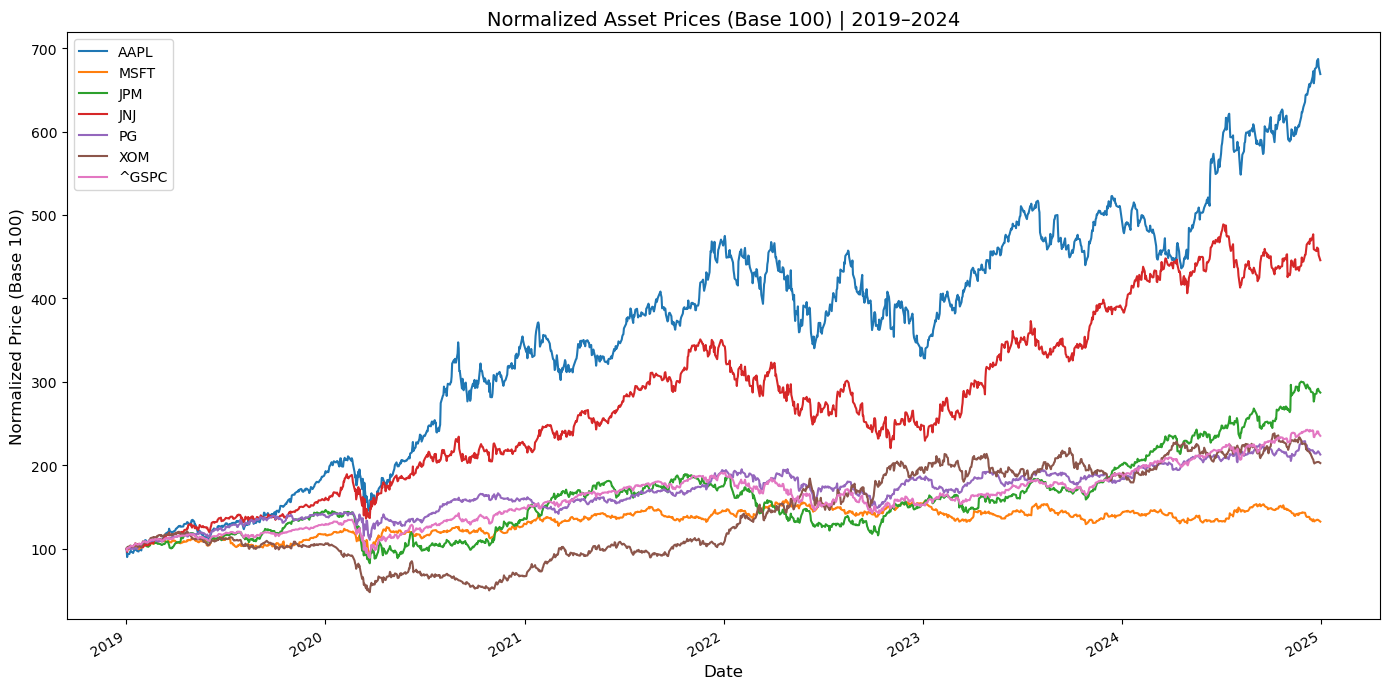

In [4]:
# --- All assets normalized (Base 100) --- 

normalization_all = (data / data.iloc[0]) * 100
 
normalization_all.plot(figsize=(14, 7))
plt.title("Normalized Asset Prices (Base 100) | 2019–2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(assets)
plt.tight_layout()
plt.show()

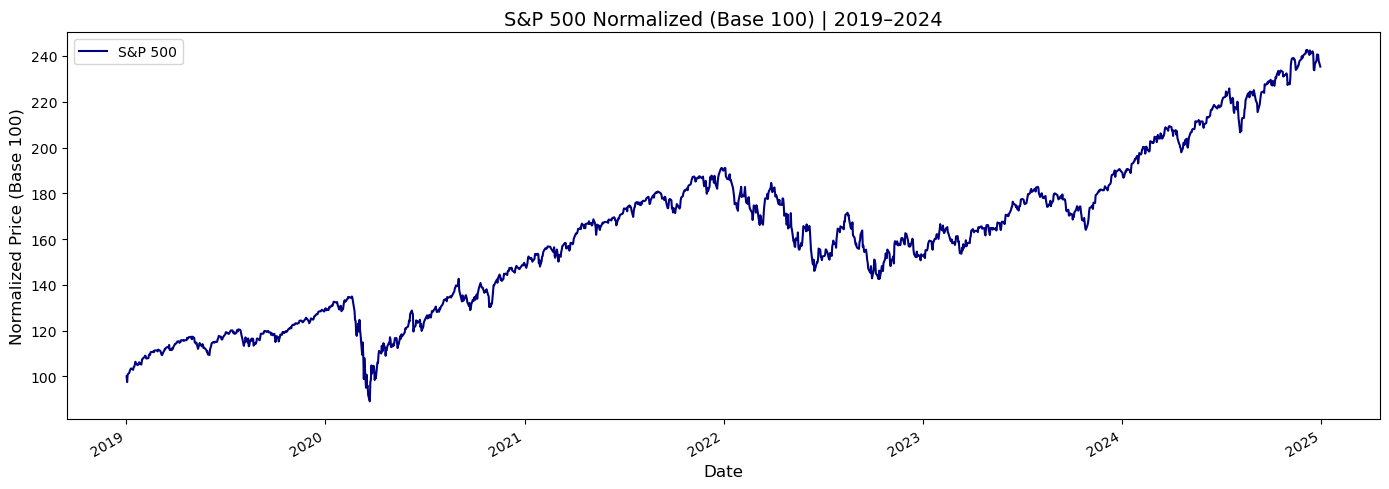

In [5]:
# --- S&P 500 standalone ---

normalization_sp500 = (data["^GSPC"] / data["^GSPC"].iloc[0]) * 100
 
normalization_sp500.plot(figsize=(14, 5), color="navy")
plt.title("S&P 500 Normalized (Base 100) | 2019–2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(["S&P 500"])
plt.tight_layout()
plt.show()

# Log Returns & Individual Asset Risk

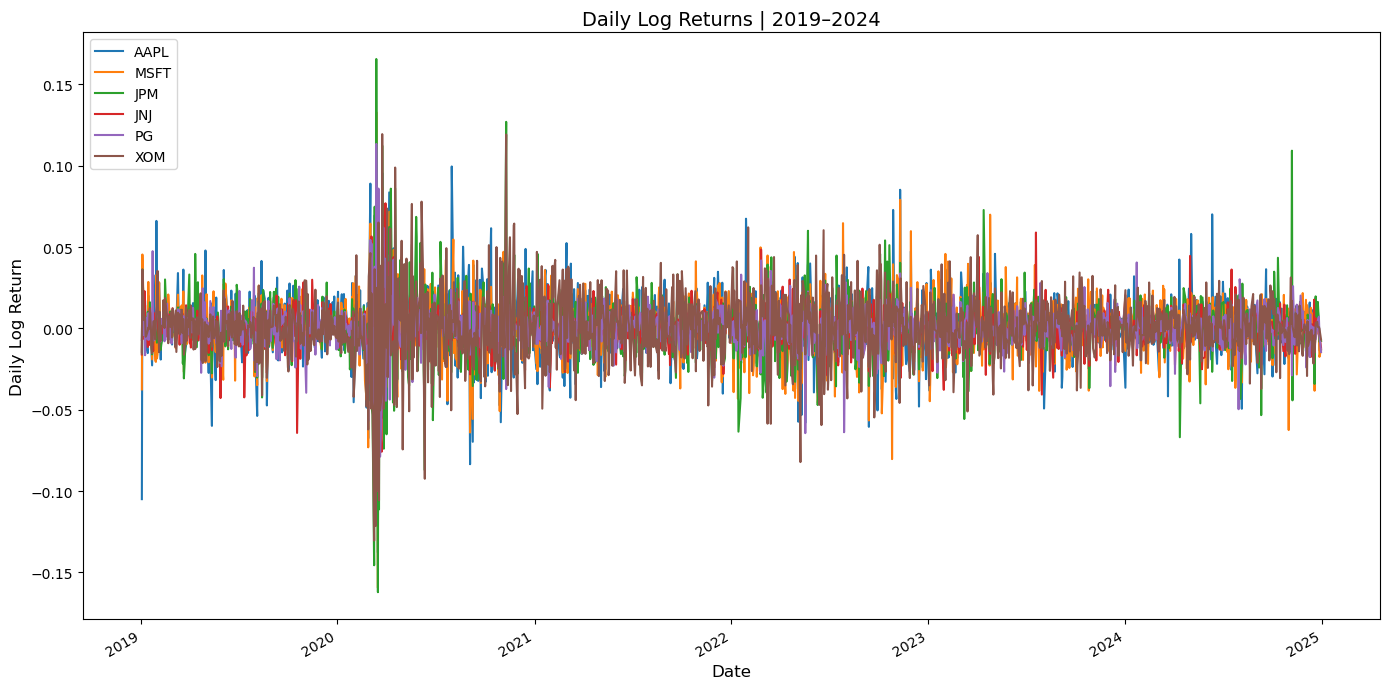

In [6]:
# --- Log Returns ---

log_return = np.log(data / data.shift(1))
 
log_return[stocks].plot(figsize=(14, 7))
plt.title("Daily Log Returns | 2019–2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Log Return", fontsize=12)
plt.legend(stocks)
plt.tight_layout()
plt.show()

In [7]:
# --- Annual Metrics (stocks only — no benchmark in portfolio) ---

annual_return  = log_return[stocks].mean() * 250
annual_variance = log_return[stocks].var() * 250
annual_std     = log_return[stocks].std() * (250 ** 0.5)

In [8]:
# --- Summary Table ---

summary = pd.DataFrame({
    "Annual Return (%)":    (annual_return  * 100).round(2),
    "Annual Variance":       annual_variance.round(6),
    "Volatility / Risk (%)": (annual_std     * 100).round(2)
})
 
print("\n===== Individual Asset Risk & Return Summary =====")
print(summary.to_string())


===== Individual Asset Risk & Return Summary =====
        Annual Return (%)  Annual Variance  Volatility / Risk (%)
Ticker                                                           
AAPL                31.50         0.094420                  30.73
MSFT                24.78         0.083592                  28.91
JPM                 17.49         0.092832                  30.47
JNJ                  4.67         0.036320                  19.06
PG                  12.53         0.040704                  20.18
XOM                 11.71         0.103260                  32.13


# Portfolio Construction

In [9]:
# Portfolio A — Equal Weight

portfolio_weight_a = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])
print(f"\nPortfolio A weights sum: {portfolio_weight_a.sum():.4f}")


Portfolio A weights sum: 1.0000


In [10]:
# Portfolio B — Conviction-Based (overweight defensives: JNJ, PG)
portfolio_weight_b = np.array([0.12, 0.12, 0.20, 0.25, 0.20, 0.11])
print(f"Portfolio B weights sum: {portfolio_weight_b.sum():.4f}")

Portfolio B weights sum: 1.0000


In [11]:
# --- Portfolio Returns ---

portfolio_return_a = np.dot(portfolio_weight_a, annual_return[stocks])
portfolio_return_b = np.dot(portfolio_weight_b, annual_return[stocks])
print(f"\nPortfolio A (Equal Weight)      Annual Return: {round(portfolio_return_a * 100, 2)}%")
print(f"Portfolio B (Conviction-Based)  Annual Return: {round(portfolio_return_b * 100, 2)}%")


Portfolio A (Equal Weight)      Annual Return: 17.11%
Portfolio B (Conviction-Based)  Annual Return: 15.21%


# Covariance & Correlation Analysis

In [12]:
# --- Covariance Matrix (annualized) ---

annual_covariance = log_return[stocks].cov() * 250
 
print("\n===== Annual Covariance Matrix =====")
print(annual_covariance.round(6))


===== Annual Covariance Matrix =====
Ticker      AAPL      MSFT       JPM       JNJ        PG       XOM
Ticker                                                            
AAPL    0.094420  0.065454  0.039002  0.021162  0.024842  0.029292
MSFT    0.065454  0.083592  0.037608  0.020377  0.025587  0.024078
JPM     0.039002  0.037608  0.092832  0.022712  0.021212  0.055914
JNJ     0.021162  0.020377  0.022712  0.036320  0.021943  0.018054
PG      0.024842  0.025587  0.021212  0.021943  0.040704  0.014326
XOM     0.029292  0.024078  0.055914  0.018054  0.014326  0.103260


In [13]:
# --- Correlation Matrix (NEVER * 250 — already dimensionless) ---

correlation_matrix = log_return[stocks].corr()
 
print("\n===== Correlation Matrix =====")
print(correlation_matrix.round(3))
print("\nDiagonal (must be all 1.0):", np.diag(correlation_matrix.values).round(3))


===== Correlation Matrix =====
Ticker   AAPL   MSFT    JPM    JNJ     PG    XOM
Ticker                                          
AAPL    1.000  0.737  0.417  0.361  0.401  0.297
MSFT    0.737  1.000  0.427  0.370  0.439  0.259
JPM     0.417  0.427  1.000  0.391  0.345  0.571
JNJ     0.361  0.370  0.391  1.000  0.571  0.295
PG      0.401  0.439  0.345  0.571  1.000  0.221
XOM     0.297  0.259  0.571  0.295  0.221  1.000

Diagonal (must be all 1.0): [1. 1. 1. 1. 1. 1.]


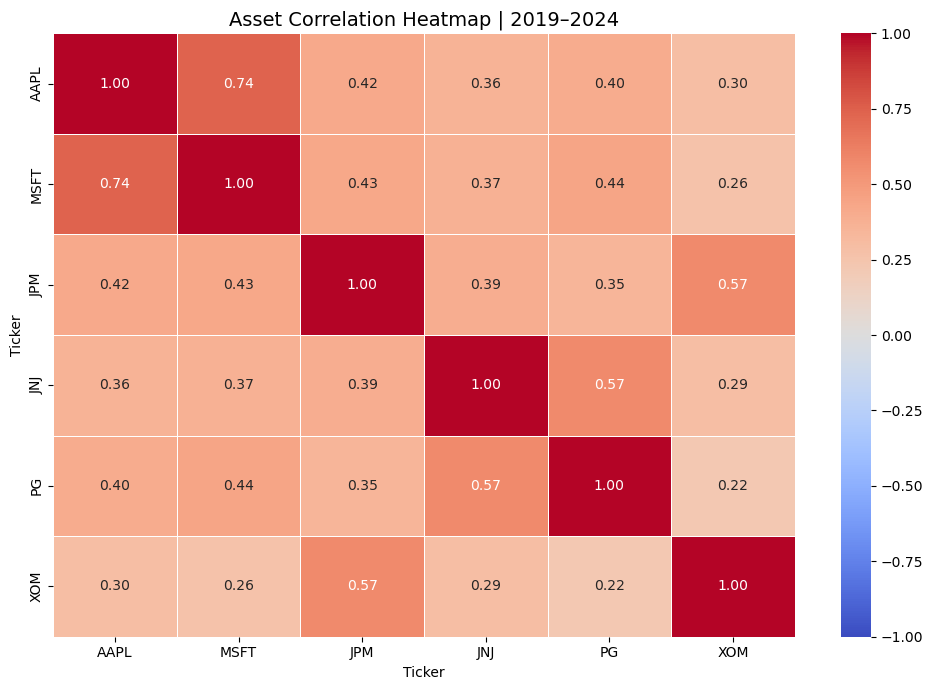

In [14]:
# --- Heatmap ---

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Asset Correlation Heatmap | 2019–2024", fontsize=14)
plt.tight_layout()
plt.show()

# Portfolio Variance & Risk Decomposition

In [15]:
# --- Portfolio Variance (Matrix Form) ---

portfolio_variance_a = np.dot(portfolio_weight_a.T, np.dot(annual_covariance, portfolio_weight_a))
portfolio_variance_b = np.dot(portfolio_weight_b.T, np.dot(annual_covariance, portfolio_weight_b))

In [16]:
# --- Portfolio Volatility ---

portfolio_volatility_a = portfolio_variance_a ** 0.5
portfolio_volatility_b = portfolio_variance_b ** 0.5

In [17]:
print("\n===== Portfolio Variance & Volatility =====")
print(f"Portfolio A | Variance: {portfolio_variance_a:.6f} | Volatility: {round(portfolio_volatility_a * 100, 2)}%")
print(f"Portfolio B | Variance: {portfolio_variance_b:.6f} | Volatility: {round(portfolio_volatility_b * 100, 2)}%")


===== Portfolio Variance & Volatility =====
Portfolio A | Variance: 0.037063 | Volatility: 19.25%
Portfolio B | Variance: 0.033555 | Volatility: 18.32%


# Systematic vs Diversifiable Risk

In [18]:
# --- Portfolio A ---

def weighted_individual_variance(weights, variances):
    return np.sum(weights**2 * variances.values)

wiv_a = weighted_individual_variance(portfolio_weight_a, annual_variance)
diversifiable_risk_a   = portfolio_variance_a - wiv_a
systematic_risk_a      = portfolio_variance_a - diversifiable_risk_a
 
print("\n===== Risk Decomposition — Portfolio A (Equal Weight) =====")
print(f"  Total Portfolio Variance : {portfolio_variance_a:.6f}")
print(f"  Systematic Risk          : {systematic_risk_a:.6f}")
print(f"  Diversifiable Risk       : {diversifiable_risk_a:.6f}")
print(f"  Verification (must=True) : {np.isclose(systematic_risk_a + diversifiable_risk_a, portfolio_variance_a)}")


===== Risk Decomposition — Portfolio A (Equal Weight) =====
  Total Portfolio Variance : 0.037063
  Systematic Risk          : 0.012531
  Diversifiable Risk       : 0.024531
  Verification (must=True) : True


In [19]:
# --- Portfolio B ---

def weighted_individual_variance(weights, variances):
    return np.sum(weights**2 * variances.values)

wiv_b = weighted_individual_variance(portfolio_weight_b, annual_variance)
diversifiable_risk_b   = portfolio_variance_b - wiv_b
systematic_risk_b      = portfolio_variance_b - diversifiable_risk_b
 
print("\n===== Risk Decomposition — Portfolio B (Conviction-Based) =====")
print(f"  Total Portfolio Variance : {portfolio_variance_b:.6f}")
print(f"  Systematic Risk          : {systematic_risk_b:.6f}")
print(f"  Diversifiable Risk       : {diversifiable_risk_b:.6f}")
print(f"  Verification (must=True) : {np.isclose(systematic_risk_b + diversifiable_risk_b, portfolio_variance_b)}")


===== Risk Decomposition — Portfolio B (Conviction-Based) =====
  Total Portfolio Variance : 0.033555
  Systematic Risk          : 0.011424
  Diversifiable Risk       : 0.022130
  Verification (must=True) : True


# Final Summary Dashboard

In [20]:
summary_portfolio = pd.DataFrame({
    "Annual Return (%)":   [round(portfolio_return_a * 100, 2),    round(portfolio_return_b * 100, 2)],
    "Volatility (%)":      [round(portfolio_volatility_a * 100, 2), round(portfolio_volatility_b * 100, 2)],
    "Variance":            [round(portfolio_variance_a, 6),          round(portfolio_variance_b, 6)],
    "Systematic Risk":     [round(systematic_risk_a, 6),             round(systematic_risk_b, 6)],
    "Diversifiable Risk":  [round(diversifiable_risk_a, 6),          round(diversifiable_risk_b, 6)],
}, index=["Portfolio A (Equal)", "Portfolio B (Conviction)"])
 
print("\n===== FINAL PORTFOLIO COMPARISON =====")
print(summary_portfolio.to_string())


===== FINAL PORTFOLIO COMPARISON =====
                          Annual Return (%)  Volatility (%)  Variance  Systematic Risk  Diversifiable Risk
Portfolio A (Equal)                   17.11           19.25  0.037063         0.012531            0.024531
Portfolio B (Conviction)              15.21           18.32  0.033555         0.011424            0.022130
